# 🐬 tank-mixing

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import trange
from typing import Tuple

from bluer_options import string

from bluer_ugv.host import signature
from bluer_ugv.logger import logger

logger.info(f"{'.'.join(signature())},\nbuilt on {string.pretty_date()}")

🐬  bluer_ugv-6.712.1.bluer_sbc-8.176.1.bluer_ai-12.257.1.bluer_objects-6.252.1.bluer_options-5.164.1.torch-2.2.2.Python 3.12.9.Darwin 23.6.0..Jupyter-Notebook,
built on 24 August 2025, 17:18:21


---

In [2]:
def tank_mixing(speed: int, steering: int) -> Tuple[int, int]:
    left = speed + steering
    right = speed - steering

    m = max(abs(left), abs(right), 100)
    left = left * 100 / m
    right = right * 100 / m

    return int(left), int(right)

100%|██████████| 200/200 [00:00<00:00, 3304.70it/s]


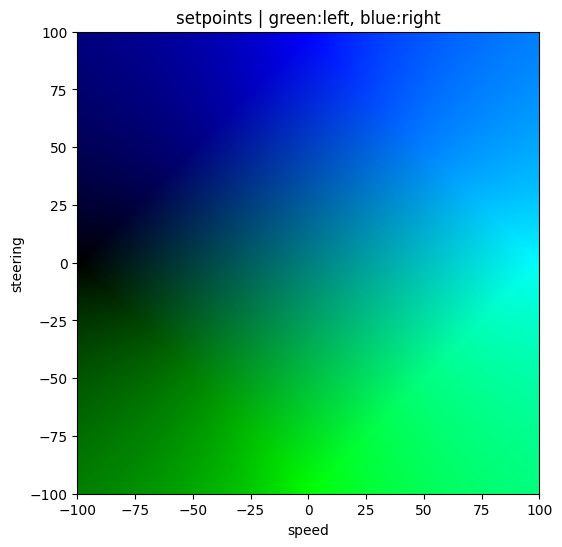

In [13]:
# image size
res = 200
img = np.zeros((res, res, 3), dtype=np.uint8)

# map -100..100 to 0..199
for i in trange(res):
    for j in range(res):
        speed = (j / (res - 1)) * 200 - 100
        steering = (i / (res - 1)) * 200 - 100
        left, right = tank_mixing(speed, steering)
        
        # normalize to 0..255, using left=green, right=blue
        g = int((left + 100) / 200 * 255)
        b = int((right + 100) / 200 * 255)
        img[res-1-i, j] = (0, g, b)

fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(img, extent=[-100,100,-100,100], origin="lower")
ax.set_xlabel("speed")
ax.set_ylabel("steering")
plt.title("setpoints | green:left, blue:right")
plt.show()

---

In [4]:
# END